# 模块 7 节点壳（`/control_mux`）调用示例

对应 `catkin_ws/src/uav_tracking/scripts/control_mux_node.py`，演示节点壳的**搬运 + 仲裁**：

1. `state_msg_to_str(msg)` —— `std_msgs/String` → `str`；
2. `ControlMux`（核，来自 `lib/control_mux.py`，软链到 `code/control_mux.py`）—— 事件转发仲裁；
3. 两路指令均用**真实** `mavros_msgs/PositionTarget`，用 `header.frame_id` 标记来源。

> **运行前提**：Jupyter 内核为系统 `python3`（「ROS Noetic (Py3.8)」），已 `source` ROS 与工作区。
> 本 notebook **不启动节点、不需 roscore**——只演示可复用的转换与仲裁逻辑（真实接线见脚本 `ControlMuxNode`）。

In [1]:
import os
import sys

# 从当前目录向上查找仓库根（含 catkin_ws），使 notebook 在任意 cwd 下都能 import 节点壳
_here = os.path.abspath('.')
_repo = _here
while _repo != os.path.dirname(_repo) and not os.path.isdir(os.path.join(_repo, 'catkin_ws')):
    _repo = os.path.dirname(_repo)
SCRIPTS = os.path.join(_repo, 'catkin_ws', 'src', 'uav_tracking', 'scripts')
if SCRIPTS not in sys.path:
    sys.path.insert(0, SCRIPTS)

import matplotlib.pyplot as plt
from mavros_msgs.msg import PositionTarget
from std_msgs.msg import String

import control_mux_node as cmn          # 节点壳（内部把 lib/ 加入 sys.path）
from control_mux import ControlMux      # 核（lib/control_mux.py 软链到 code/）

# 字体 / 配色统一（雷达蓝、视觉紫，与 design/函数接口.md 模块着色一致）
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print('SETPOINT_TOPIC =', cmn.SETPOINT_TOPIC)
print('STATE_TOPIC    =', cmn.STATE_TOPIC)
print('INITIAL_STATE  =', cmn.INITIAL_STATE)

SETPOINT_TOPIC = /mavros/setpoint_raw/local
STATE_TOPIC    = /state
INITIAL_STATE  = RADAR_GUIDE


## 0. 构造两路指令与状态消息

`/ctrl/radar` 与 `/ctrl/visual` 两路都用 `mavros_msgs/PositionTarget`；mux **不解析指令内容**，
只按来源通道与当前状态决定放行 / 丢弃——用 `header.frame_id` 标记来源便于观察。

In [2]:
C_RADAR = '#1565c0'   # 雷达蓝（与 design 着色一致）
C_VISUAL = '#7b1fa2'  # 视觉紫
C_DROP = '#9e9e9e'    # 丢弃灰


def target(frame_id, x):
    """构造一条带来源标记的 PositionTarget（mux 视指令为不透明对象）。"""
    m = PositionTarget()
    m.header.frame_id = frame_id
    m.position.x = x
    return m


RADAR = target('radar_src', 1.0)
VISUAL = target('visual_src', 2.0)
print('雷达指令:', RADAR.header.frame_id, '| position.x =', RADAR.position.x)
print('视觉指令:', VISUAL.header.frame_id, '| position.x =', VISUAL.position.x)

雷达指令: radar_src | position.x = 1.0
视觉指令: visual_src | position.x = 2.0


## 1. 状态消息转换 `state_msg_to_str`

`/state` 为 `std_msgs/String`，节点壳取出 `msg.data` 交给核；空串按「未知状态」处理（回退雷达）。

In [3]:
for s in ['RADAR_GUIDE', 'VISUAL_LOCK', 'SEARCH/RTH', '']:
    print('%-12r -> %r' % (s, cmn.state_msg_to_str(String(data=s))))

'RADAR_GUIDE' -> 'RADAR_GUIDE'
'VISUAL_LOCK' -> 'VISUAL_LOCK'
'SEARCH/RTH' -> 'SEARCH/RTH'
''           -> ''


## 2. 事件转发仲裁（核 `ControlMux`）

模拟节点回调序列：两路指令交替到达，`/state` 中途切换。
mux **收到即判**：当前放行通道的指令转发到 `/mavros/setpoint_raw/local`，另一路丢弃。

In [4]:
mux = ControlMux(cmn.INITIAL_STATE)

# 模仿节点回调：('state', s) → on_state；('cmd', 通道, 指令) → on_command
events = [
    ('cmd',   '/ctrl/radar',  RADAR),
    ('cmd',   '/ctrl/visual', VISUAL),      # 当前雷达态 → 视觉指令被丢弃
    ('state', 'VISUAL_LOCK'),
    ('cmd',   '/ctrl/radar',  RADAR),       # 视觉态 → 雷达指令被丢弃
    ('cmd',   '/ctrl/visual', VISUAL),
    ('state', 'SEARCH/RTH'),                # 兜底态 → 回退雷达
    ('cmd',   '/ctrl/visual', VISUAL),
    ('cmd',   '/ctrl/radar',  RADAR),
]

rows = []
for ev in events:
    if ev[0] == 'state':
        mux.on_state(ev[1])
        rows.append((mux.state, 'state', 'state -> ' + ev[1]))
    else:
        _, ch, msg = ev
        out = mux.on_command(ch, msg)
        rows.append((mux.state, msg.header.frame_id,
                     '转发 -> ' + cmn.SETPOINT_TOPIC if out is not None else '丢弃'))

print('%-14s %-12s %s' % ('当前状态', '指令来源', '结果'))
print('-' * 56)
for st, src, res in rows:
    print('%-14s %-12s %s' % (st, src, res))

当前状态           指令来源         结果
--------------------------------------------------------
RADAR_GUIDE    radar_src    转发 -> /mavros/setpoint_raw/local
RADAR_GUIDE    visual_src   丢弃
VISUAL_LOCK    state        state -> VISUAL_LOCK
VISUAL_LOCK    radar_src    丢弃
VISUAL_LOCK    visual_src   转发 -> /mavros/setpoint_raw/local
SEARCH/RTH     state        state -> SEARCH/RTH
SEARCH/RTH     visual_src   丢弃
SEARCH/RTH     radar_src    转发 -> /mavros/setpoint_raw/local


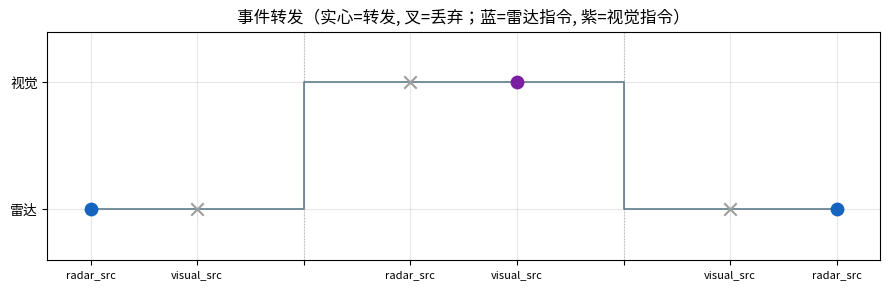

In [5]:
# 时序图：状态阶梯 + 指令放行/丢弃标记
ymap = {'RADAR_GUIDE': 0, 'VISUAL_LOCK': 1, 'SEARCH/RTH': 0}
xs = list(range(len(rows)))
ys = [ymap.get(st, 0) for st, _, _ in rows]

fig, ax = plt.subplots(figsize=(9, 3.0))
ax.step(xs, ys, where='post', color='#607d8b', lw=1.2,
        label='当前通道（0=雷达, 1=视觉）')
for i, (st, src, res) in enumerate(rows):
    if src == 'state':
        ax.axvline(i, color='#bdbdbd', ls=':', lw=0.8, zorder=1)
        continue
    ch_color = C_VISUAL if src == 'visual_src' else C_RADAR
    fwd = res.startswith('转发')
    ax.scatter(i, ymap.get(st, 0), color=ch_color if fwd else C_DROP,
               marker='o' if fwd else 'x', s=80, zorder=3)
ax.set_xticks(xs)
ax.set_xticklabels(['' if src == 'state' else src for _, src, _ in rows], fontsize=8)
ax.set_yticks([0, 1])
ax.set_yticklabels(['雷达', '视觉'])
ax.set_ylim(-0.4, 1.4)
ax.set_title('事件转发（实心=转发, 叉=丢弃；蓝=雷达指令, 紫=视觉指令）')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. 说明

真实运行时，`ControlMuxNode` 用 `rospy` 接线（见 `control_mux_node.py`）：

- 订阅 `/state` (`std_msgs/String`)、`/ctrl/radar`、`/ctrl/visual` (`mavros_msgs/PositionTarget`)；
- 回调即调 `ControlMux`（**事件转发、无定时器**）；选中则**原样**发布到 `/mavros/setpoint_raw/local`，否则丢弃；
- 每路 `queue_size=1`（只留最新一条）；**不做 `/state` 超时检测**（方案 B，靠 `stop_setpoint` + PX4 failsafe 兜底）。

本节演示的 `state_msg_to_str` + `ControlMux` 与节点壳共用同一份核（`lib/` 软链 → `code/`），**零代码漂移**。